## Step 1: Environment Setup and Data Collection

Proper environment setup ensures reproducibility. Data collection is the foundation of any data science project.

In [ ]:
# Import core libraries
import os
import sys
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set up data directory
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

# Download datasets (example for Amazon reviews)
import requests
from zipfile import ZipFile

def download_dataset(url, save_path):
    """Download and extract dataset"""
    if not os.path.exists(save_path):
        print("Downloading dataset...")
        r = requests.get(url)
        with open(save_path, 'wb') as f:
            f.write(r.content)
        
        # Extract if zip file
        if save_path.endswith('.zip'):
            with ZipFile(save_path, 'r') as zip_ref:
                zip_ref.extractall(DATA_DIR)
        print("Dataset downloaded and extracted!")
    else:
        print("Dataset already exists!")

# Example URL (replace with actual dataset URL)
amazon_reviews_url = "https://www.kaggle.com/datasets/mexwell/amazon-reviews-multi?select=train.csv"
download_dataset(amazon_reviews_url, os.path.join(DATA_DIR, "amazon_reviews.zip"))

## Step 2: Data Loading and Initial Exploration

Understanding data structure, identifying missing values, and getting initial insights.

In [2]:
# Load the dataset
df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

In [3]:
# Initial exploration
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nData types and missing values:")
print(df.info())
print("\nBasic statistics:")
print(df.describe(include='all'))

Dataset shape: (30000, 9)

First 5 rows:
   Unnamed: 0   review_id          product_id          reviewer_id  stars  \
0           0  de_0784695  product_de_0572654  reviewer_de_0645436      1   
1           1  de_0759207  product_de_0567331  reviewer_de_0183703      1   
2           2  de_0711785  product_de_0482105  reviewer_de_0182152      1   
3           3  de_0964430  product_de_0616480  reviewer_de_0991563      1   
4           4  de_0474538  product_de_0228702  reviewer_de_0316188      1   

                                         review_body  \
0  Leider, leider nach einmal waschen ausgebliche...   
1  zunächst macht der Anker Halter einen soliden ...   
2  Siegel sowie Verpackung war beschädigt und war...   
3  Habe dieses Produkt NIE erhalten und das Geld ...   
4                 Die Träger sind schnell abgerissen   

                       review_title language     product_category  
0         Leider nicht zu empfehlen       de                 home  
1  Gummierung nach 6 Mo

In [4]:
# Check language distribution
print("\nLanguage distribution:")
print(df['language'].value_counts())


Language distribution:
language
de    5000
en    5000
es    5000
fr    5000
ja    5000
zh    5000
Name: count, dtype: int64


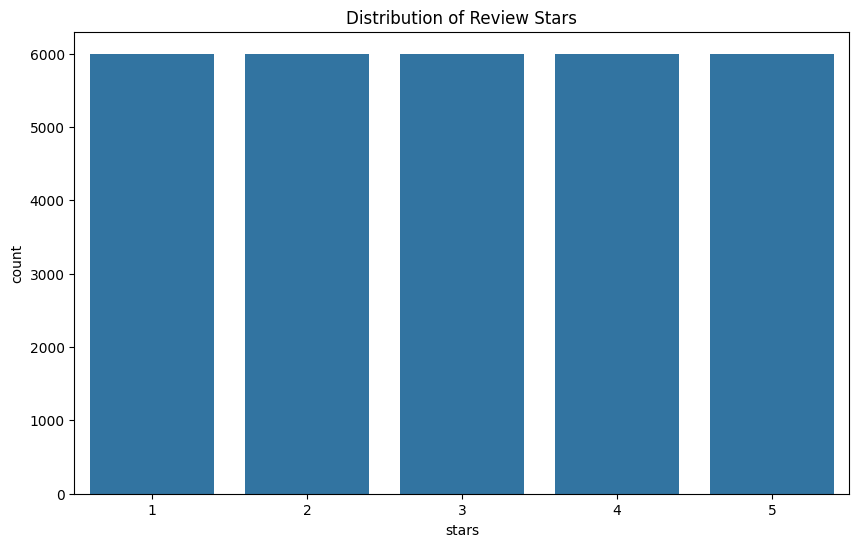

In [5]:
# Check stars distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='stars', data=df)
plt.title('Distribution of Review Stars')
plt.show()

## Step 3: Language Detection and Validation

Ensures we're working with correctly identified languages for proper NLP processing.

In [6]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42  # for reproducibility

def detect_language(text):
    try:
        return detect(text)
    except:
        return 'unknown'

# Sample detection on a subset for performance
sample_df = df.sample(1000, random_state=42)
sample_df['detected_lang'] = sample_df['review_body'].apply(detect_language)

In [7]:
# Compare with provided language if available

if 'language' in sample_df.columns:
    from sklearn.metrics import classification_report
    print(classification_report(
        sample_df['language'], 
        sample_df['detected_lang'],
        zero_division=0
    ))

              precision    recall  f1-score   support

          af       0.00      0.00      0.00         0
          ca       0.00      0.00      0.00         0
          de       0.99      1.00      1.00       162
          en       0.99      0.98      0.99       165
          es       1.00      1.00      1.00       188
          fr       1.00      0.98      0.99       161
          ja       1.00      1.00      1.00       166
          ko       0.00      0.00      0.00         0
          no       0.00      0.00      0.00         0
          zh       0.00      0.00      0.00       158
       zh-cn       0.00      0.00      0.00         0

    accuracy                           0.84      1000
   macro avg       0.45      0.45      0.45      1000
weighted avg       0.84      0.84      0.84      1000



In [8]:
# Add language detection to full dataset if needed
df['detected_language'] = 'unknown'
for i, row in df.iterrows():
    if i % 5000 == 0:
        print(f"Processing row {i}/{len(df)}")
    df.at[i, 'detected_language'] = detect_language(row['review_body'])

Processing row 0/30000
Processing row 5000/30000
Processing row 10000/30000
Processing row 15000/30000
Processing row 20000/30000
Processing row 25000/30000


## Step 4: Text Preprocessing Pipeline

Clean, normalized text improves model performance and reduces noise.

In [ ]:
import re
import spacy
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Initialize language-specific tools
language_tools = {
    'en': {
        'nlp': spacy.load('en_core_web_sm'),
        'stopwords': set(stopwords.words('english')),
        'stemmer': SnowballStemmer('english')
    },
    'es': {
        'nlp': spacy.load('es_core_news_sm'),
        'stopwords': set(stopwords.words('spanish')),
        'stemmer': SnowballStemmer('spanish')
    },
    'fr': {
        'nlp': spacy.load('fr_core_news_sm'),
        'stopwords': set(stopwords.words('french')),
        'stemmer': SnowballStemmer('french')
    },
    'de': {
        'nlp': spacy.load('de_core_news_sm'),
        'stopwords': set(stopwords.words('german')),
        'stemmer': SnowballStemmer('german')
    }
}

def preprocess_text(text, language='en'):
    """Clean and preprocess text based on language"""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    
    # Get language tools (default to English if language not supported)
    tools = language_tools.get(language, language_tools['en'])
    nlp = tools['nlp']
    stop_words = tools['stopwords']
    stemmer = tools['stemmer']
    
    # Basic cleaning
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # URLs
    text = re.sub(r'\@\w+|\#\w+', '', text)  # Mentions and hashtags
    text = re.sub(r'[^\w\s]', '', text)  # Punctuation
    text = re.sub(r'\d+', '', text)  # Numbers
    
    # Tokenization and lemmatization with SpaCy
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_space]
    
    # Stopword removal and stemming
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)

In [ ]:
# Apply preprocessing to the dataset
df['processed_text'] = df.apply(
    lambda row: preprocess_text(row['review_text'], row['detected_language']), 
    axis=1
)

In [ ]:
# Save processed data
df.to_csv(os.path.join(DATA_DIR, 'processed_reviews.csv'), index=False)

## Step 5: Exploratory Data Analysis (EDA)

Reveals patterns, outliers, and relationships in the data.

In [ ]:
# 1. Text Length Analysis
df['text_length'] = df['processed_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(12, 6))
sns.boxplot(x='review_rating', y='text_length', data=df)
plt.title('Text Length by Rating')
plt.show()

In [ ]:
# 2. Word Clouds for Different Languages
from wordcloud import WordCloud

def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, 
                         background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

for lang in ['en', 'es', 'fr', 'de']:
    lang_text = ' '.join(df[df['detected_language'] == lang]['processed_text'])
    generate_wordcloud(lang_text, f'Word Cloud for {lang.upper()} Reviews')

In [ ]:
# 3. Sentiment Analysis by Language
from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

df['sentiment'] = df['processed_text'].apply(get_sentiment)

plt.figure(figsize=(12, 6))
sns.boxplot(x='detected_language', y='sentiment', data=df)
plt.title('Sentiment Distribution by Language')
plt.show()

In [ ]:
# 4. Topic Modeling (LDA)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# For English reviews only for this example
en_reviews = df[df['detected_language'] == 'en']['processed_text']

# Vectorize text
vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=1000)
X = vectorizer.fit_transform(en_reviews)

# Fit LDA model
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# Display topics
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda, vectorizer.get_feature_names_out(), 10)

## Step 6: Feature Engineering

Transforms raw data into features that better represent the problem.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# 1. Language encoding
le = LabelEncoder()
df['language_encoded'] = le.fit_transform(df['detected_language'])

In [ ]:
# 2. TF-IDF Vectorization
# We'll create separate vectorizers for each major language
vectorizers = {}
tfidf_features = {}

for lang in ['en', 'es', 'fr', 'de']:
    lang_data = df[df['detected_language'] == lang]
    if len(lang_data) > 0:
        vectorizer = TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2),
            stop_words=language_tools[lang]['stopwords']
        )
        tfidf = vectorizer.fit_transform(lang_data['processed_text'])
        tfidf_features[lang] = tfidf
        vectorizers[lang] = vectorizer
        print(f"Created TF-IDF for {lang} with {tfidf.shape[1]} features")

In [ ]:
# 3. Sentiment features
df['sentiment_binary'] = df['sentiment'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
# 4. Text length features
df['text_length_category'] = pd.cut(
    df['text_length'],
    bins=[0, 10, 20, 50, 100, np.inf],
    labels=['very_short', 'short', 'medium', 'long', 'very_long']
)

In [ ]:
# 5. Time-based features
if 'review_date' in df.columns:
    df['review_date'] = pd.to_datetime(df['review_date'])
    df['review_year'] = df['review_date'].dt.year
    df['review_month'] = df['review_date'].dt.month
    df['review_day_of_week'] = df['review_date'].dt.dayofweek

# Save features
df.to_csv(os.path.join(DATA_DIR, 'features_reviews.csv'), index=False)

## Step 7: Model Building - Sentiment Analysis

Creates predictive models to automate sentiment classification.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# We'll build a model for English reviews first
en_df = df[df['detected_language'] == 'en'].copy()

# Create target variable (binary sentiment: positive/negative)
en_df['sentiment_label'] = en_df['review_rating'].apply(
    lambda x: 'positive' if x > 3 else 'negative' if x < 3 else 'neutral')
en_df = en_df[en_df['sentiment_label'] != 'neutral']  # Remove neutrals for binary classification

In [ ]:
# Get features and labels
X = tfidf_features['en'][en_df.index]
y = en_df['sentiment_label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Logistic Regression Results:")
print(classification_report(y_test, y_pred))

In [ ]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("\nRandom Forest Results:")
print(classification_report(y_test, y_pred))

In [ ]:
# Model 3: SVM
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("\nSVM Results:")
print(classification_report(y_test, y_pred))

In [ ]:
# Save the best model (Logistic Regression in this case)
import joblib
joblib.dump(lr, 'models/sentiment_lr_model.pkl')
joblib.dump(vectorizers['en'], 'models/tfidf_vectorizer.pkl')

## Step 8: Hyperparameter Tuning

Optimizes model performance by finding the best parameters.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

In [ ]:
# Create grid search
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [ ]:
# Fit grid search
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search.best_score_))


In [ ]:
# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("\nOptimized Model Results:")
print(classification_report(y_test, y_pred))

# Save the optimized model
joblib.dump(best_model, 'models/sentiment_optimized_model.pkl')

## Step 9: Model Evaluation and Interpretation

Understands model performance and behavior.

In [ ]:
# 1. Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=best_model.classes_)
disp.plot()
plt.title('Confusion Matrix for Sentiment Analysis')
plt.show()

In [ ]:
# 2. Feature Importance
def plot_top_features(model, vectorizer, n=20):
    """Plot top positive and negative features"""
    feature_names = vectorizer.get_feature_names_out()
    coef = model.coef_.ravel()
    
    # Get top positive and negative coefficients
    top_positive = np.argsort(coef)[-n:]
    top_negative = np.argsort(coef)[:n]
    
    # Create plot
    plt.figure(figsize=(15, 8))
    
    # Positive features
    plt.subplot(1, 2, 1)
    plt.barh(range(n), coef[top_positive])
    plt.yticks(range(n), [feature_names[i] for i in top_positive])
    plt.title("Top Positive Features")
    
    # Negative features
    plt.subplot(1, 2, 2)
    plt.barh(range(n), coef[top_negative])
    plt.yticks(range(n), [feature_names[i] for i in top_negative])
    plt.title("Top Negative Features")
    
    plt.tight_layout()
    plt.show()

plot_top_features(best_model, vectorizers['en'])

In [ ]:
# 3. Cross-validate on different languages
def evaluate_on_language(lang, model, vectorizer):
    """Evaluate model on a different language"""
    lang_df = df[df['detected_language'] == lang].copy()
    if len(lang_df) == 0:
        print(f"No data for language {lang}")
        return
    
    # Prepare labels
    lang_df['sentiment_label'] = lang_df['review_rating'].apply(
        lambda x: 'positive' if x > 3 else 'negative' if x < 3 else 'neutral')
    lang_df = lang_df[lang_df['sentiment_label'] != 'neutral']
    
    if len(lang_df) == 0:
        print(f"No binary sentiment data for language {lang}")
        return
    
    # Vectorize text
    X_lang = vectorizer.transform(lang_df['processed_text'])
    y_lang = lang_df['sentiment_label']
    
    # Predict and evaluate
    y_pred = model.predict(X_lang)
    print(f"\nEvaluation on {lang} language:")
    print(classification_report(y_lang, y_pred))

In [ ]:
# Evaluate on Spanish
evaluate_on_language('es', best_model, vectorizers['en'])